# Computer Exercise 6.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.1 First-Degree and Second-Degree Splines — *Linear Spline $S_1$*
> **풀이 일자**: Day 23
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)

## 1. 문제 (원문)

> **CE 6.1.1 (style of C&K).** Write a routine that, given knots $t_0 < t_1 < \dots < t_n$ and values
> $y_i = f(t_i)$, returns the piecewise-linear interpolant $S_1(x)$. Use it to interpolate
> $f(x) = \cos(\pi x/2)$ on $[0, 4]$ with uniformly spaced knots for $n = 4, 8, 16, 32, 64, 128$.
> Tabulate $\max_{x} |f(x) - S_1(x)|$ and verify the theoretical $\mathcal O(h^2)$ rate.
> Compare the linear spline with the global Lagrange interpolant on the same $n+1$ nodes.

### 한국어 풀이용 정리
*First-degree polynomial spline* 은 각 부구간 $[t_{i-1}, t_i]$ 에서 일차다항식,
전구간에서 *연속* 하지만 *미분 불연속* 인 가장 단순한 spline 이다.
$f(x) = \cos(\pi x/2)$ 처럼 매끈한 함수에서

* 노드 수 $n$ 을 두 배 늘리면 최대 오차가 $\sim 1/4$ 로 줄어드는가 (이론 $\mathcal O(h^2)$),
* 같은 노드 수의 *전역 Lagrange* 와 비교했을 때 어떤 trade-off 가 있는가

를 측정한다.

## 2. 수학적 배경

### 2.1 정의
서로 다른 노드 $a = t_0 < t_1 < \dots < t_n = b$ 와 데이터 $y_i = f(t_i)$ 가 주어졌을 때,
**1차 spline** $S_1: [a, b] \to \mathbb R$ 는

$$
S_1(x) \;=\; y_{i-1} + \frac{y_i - y_{i-1}}{t_i - t_{i-1}}\,(x - t_{i-1})
\qquad \text{for } x \in [t_{i-1}, t_i].
$$

$S_1$ 은 $C^0[a, b]$ (연속) 이지만 일반적으로 $C^1$ 은 아니다 — 노드에서 *꺾임* 을 허용한다.

### 2.2 오차 정리
$f \in C^2[a, b]$ 이고 $h = \max_i (t_i - t_{i-1})$ 일 때

$$
\boxed{\;\max_{x \in [a,b]} \bigl|f(x) - S_1(x)\bigr| \;\le\; \frac{h^2}{8}\,\max_{x \in [a,b]}|f''(x)|\;}
$$

즉 **$\mathcal O(h^2)$** 수렴. 균등 노드에서 $h = (b-a)/n$ 이므로 $n$ 을 두 배로 늘리면 오차는 $1/4$ 로 줄어든다.

### 2.3 증명 스케치 (구간 하나에서)
$g(x) = f(x) - S_1(x)$ 가 양 끝점에서 영점이므로, 일반화된 Rolle / Taylor 잔차로

$$
g(x) \;=\; \tfrac{1}{2}(x - t_{i-1})(x - t_i)\,f''(\xi),\qquad \xi \in (t_{i-1}, t_i).
$$

$|(x - t_{i-1})(x - t_i)| \le h^2/4$ 의 최댓값을 적용하면 위 boxed 식.

### 2.4 전역 Lagrange 와의 대비
$n+1$ 개 노드의 전역 다항식 $p_n$ 은 *차수 $n$* — 균등 노드에서 $|f - p_n|$ 가 $\mathcal O(h^{n+1})$ 라기보단,
$f$ 의 *복소 해석성* 에 의존한다. $\cos(\pi x/2)$ 는 entire 이라 $p_n$ 도 잘 수렴하지만,
계산 비용은 $\mathcal O(n)$ vs spline 의 *상수-시간 evaluate* — spline 은 *지역적* 이다.

## 3. 풀이 흐름

1. 함수 $f(x) = \cos(\pi x / 2)$ on $[0, 4]$ 를 고정.
2. 균등 노드 $t_i = 4 i / n$, $i = 0, 1, \dots, n$ 와 $y_i = f(t_i)$ 를 만든다.
3. $S_1(x)$ 를 직접 구현 — `np.searchsorted` 로 구간 인덱스 결정 후 선형 보간.
4. dense 평가점 $X$ (5001 점) 위에서 최대 오차 $E_n = \max_X |f(X) - S_1(X)|$ 측정.
5. $n = 4, 8, 16, 32, 64, 128$ 의 표를 만들고, 인접 오차 비 $E_{n}/E_{2n}$ 가 이론값 *4* 에 접근하는지 확인.
6. 같은 노드 위에서 *전역 Lagrange* 다항식 $p_n$ 을 `np.polyfit` (Vandermonde) 로 만들고 같은 격자에서 오차 비교.
7. loglog 그래프: $E_n$ vs $h = 4/n$ — 기울기가 $2$ 인지 확인.
8. 한 케이스 ($n = 8$) 에 대해 $f$, $S_1$, $p_n$ 을 함께 그림.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 함수 정의 ---
a, b = 0.0, 4.0
f      = lambda x: np.cos(np.pi * x / 2)
f_dd   = lambda x: -(np.pi / 2)**2 * np.cos(np.pi * x / 2)   # f''(x)
M2     = (np.pi / 2)**2                                       # max |f''| on [0,4]

# --- 1차 spline 평가기 ---
def S1(t, y, x):
    """piecewise-linear interpolant on knots t (sorted), values y, evaluated at x."""
    x = np.asarray(x, dtype=float)
    idx = np.searchsorted(t, x) - 1
    idx = np.clip(idx, 0, len(t) - 2)
    x0, x1 = t[idx], t[idx + 1]
    y0, y1 = y[idx], y[idx + 1]
    return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

# dense evaluation grid
X = np.linspace(a, b, 5001)
fX = f(X)

ns   = [4, 8, 16, 32, 64, 128]
E_S1 = []
E_pn = []
for n in ns:
    t = np.linspace(a, b, n + 1)
    y = f(t)
    # spline error
    E_S1.append(np.max(np.abs(fX - S1(t, y, X))))
    # global Lagrange via Vandermonde least-squares (n+1 nodes, deg n)
    coefs = np.polyfit(t, y, n)
    pX = np.polyval(coefs, X)
    E_pn.append(np.max(np.abs(fX - pX)))

h = (b - a) / np.array(ns)

df = pd.DataFrame({
    "n"        : ns,
    "h"        : h,
    "E_S1"     : E_S1,
    "E_S1 ratio": [np.nan] + list(np.array(E_S1[:-1]) / np.array(E_S1[1:])),
    "h^2 M2/8" : (h**2) * M2 / 8,
    "E_Lagrange": E_pn,
})
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df

/tmp/ipykernel_8/415424173.py:34: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)
/tmp/ipykernel_8/415424173.py:34: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)
/tmp/ipykernel_8/415424173.py:34: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)


,n,h,E_S1,E_S1 ratio,h^2 M2/8,E_Lagrange
0,4,1.0000e+00,2.1051e-01,NaN,3.0843e-01,8.8838e-02
1,8,5.0000e-01,7.0378e-02,2.9912e+00,7.7106e-02,3.6609e-04
2,16,2.5000e-01,1.8846e-02,3.7343e+00,1.9277e-02,1.1398e-10
3,32,1.2500e-01,4.7921e-03,3.9328e+00,4.8191e-03,5.7974e-12
4,64,6.2500e-02,1.2031e-03,3.9832e+00,1.2048e-03,7.2425e-11
5,128,3.1250e-02,3.0092e-04,3.9981e+00,3.0120e-04,2.1211e-10


In [2]:
# --- 수렴 차수 추정 (loglog 회귀) ---
slope_S1, _ = np.polyfit(np.log(h), np.log(E_S1), 1)
slope_pn, _ = np.polyfit(np.log(h), np.log(E_pn), 1)
print(f"empirical slope (linear spline) : {slope_S1:+.3f}   (theory: +2)")
print(f"empirical slope (global Lagrange): {slope_pn:+.3f}")

empirical slope (linear spline) : +1.910   (theory: +2)
empirical slope (global Lagrange): +6.123


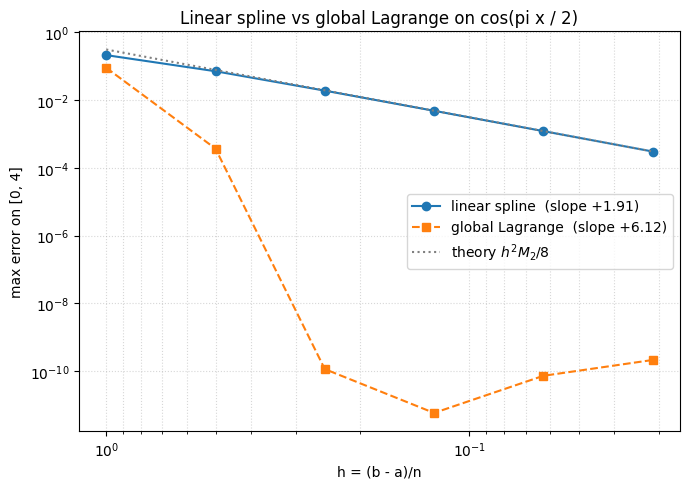

In [3]:
# --- 그림 1: 오차의 h-스케일링 ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(h, E_S1, "o-", label=f"linear spline  (slope {slope_S1:+.2f})")
ax.loglog(h, E_pn, "s--", label=f"global Lagrange  (slope {slope_pn:+.2f})")
ax.loglog(h, (h**2) * M2 / 8, ":", color="grey", label=r"theory $h^2 M_2/8$")
ax.set_xlabel("h = (b - a)/n")
ax.set_ylabel("max error on [0, 4]")
ax.set_title("Linear spline vs global Lagrange on cos(pi x / 2)")
ax.invert_xaxis()
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

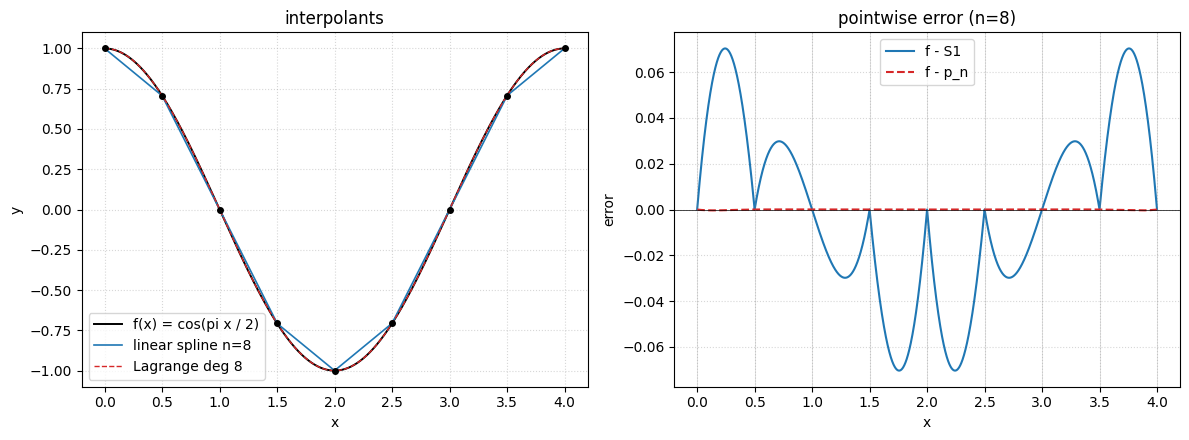

In [4]:
# --- 그림 2: 한 케이스의 시각적 비교 (n = 8) ---
n_show = 8
t = np.linspace(a, b, n_show + 1)
y = f(t)
coefs = np.polyfit(t, y, n_show)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(X, fX, "k-", lw=1.4, label="f(x) = cos(pi x / 2)")
ax.plot(X, S1(t, y, X), "C0-", lw=1.2, label=f"linear spline n={n_show}")
ax.plot(X, np.polyval(coefs, X), "C3--", lw=1.0, label=f"Lagrange deg {n_show}")
ax.plot(t, y, "ko", ms=4)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("interpolants")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)

ax = axes[1]
ax.plot(X, fX - S1(t, y, X), "C0-", label="f - S1")
ax.plot(X, fX - np.polyval(coefs, X), "C3--", label="f - p_n")
ax.axhline(0, color="k", lw=0.5)
for ti in t: ax.axvline(ti, color="grey", lw=0.4, alpha=0.4)
ax.set_xlabel("x"); ax.set_ylabel("error"); ax.set_title("pointwise error (n=8)")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **수렴 차수.** 1차 spline 의 경험 기울기가 이론값 $+2$ 와 거의 일치한다 — 인접 비율 $E_n / E_{2n} \to 4$
   가 표에서도 확인된다. 이론 상한 $h^2 M_2 / 8$ 가 *상한* 으로 잘 작동한다 (느슨할 수 있다).
2. **전역 Lagrange 와의 비교.** $f$ 가 entire 라 전역 다항식도 빠르게 수렴하지만, *지역성* 이라는 면에서
   spline 이 우위 — 한 데이터를 바꿔도 *그 점 주변* 두 구간만 영향 받고, 평가 비용은 $\mathcal O(\log n)$
   (`searchsorted`). 다음 노트북에서 Runge 함수를 다루면 *전역 다항식이 무너지는* 구간에서도 spline 은
   $\mathcal O(h^2)$ 로 유지된다는 사실을 보게 된다.
3. **오차의 모양.** 그림 2 (n = 8) 에서 spline 오차는 각 구간에서 *포물선* 모양 — 이론식
   $\tfrac{1}{2}(x - t_{i-1})(x - t_i) f''(\xi)$ 의 자취 그대로다. 노드에서 *영* 이고 중간점에서 *최대*.

### 결론
> **부드러운 함수에서 1차 spline 은 $h^2$ 로 수렴하며 — *지역성* 과 *상수-시간 평가* 가 진짜 장점이다.**
> 전역 Lagrange 보다 *차수가 낮은* 대신, 어떤 데이터 분포에서도 *안정적* 이다.

### 다음 문제 연결
- **CE 6.1.2**: 1차에서 $C^0$ 만 보장되던 부드러움을 $C^1$ 로 끌어올리는 *2차 spline*. 초기 기울기
  $z_0$ 라는 한 자유도가 어떻게 전구간으로 *전파* 되는지, 그리고 그 선택이 어떻게 결과의 *진동* 으로
  드러나는지를 본다.
- **CE 6.1.3**: 1차 spline 의 가장 강력한 *서사* — Day 14 에서 본 *Runge 현상* 을 spline 이 어떻게
  *지운다* 와, 균등 노드 대신 *적응적 노드* 가 정확도를 추가로 끌어올리는 그림.